# Regresjon - temperaturer i Bergen

Vi går nå tilbake til temperaturdata slik som vi så på i [notisboken om dataanalyse](../uke3/K1_dataanalyse.ipynb) i kursets første uke.

I de første cellene leser vi inn data på nytt.

In [1]:
# Her importeres Point og Daily funksjonalitetene fra meteostat modulen.
# Hvis meteostat ikke allerede er installert blir den installert.

try:
  import meteostat as ms
except:
  !pip install meteostat==2.0.0
  import meteostat as ms

In [2]:
# Her importeres modulen pandas som pd

import pandas as pd

In [32]:
# Vi importerer numpy til bruk senere
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Her importeres funksjonaliteten datetime fra modulen datetime.
# Datetime gir oss en bekvem måte å jobbe med tidsdate på.

from datetime import datetime, timedelta

In [5]:
# Sett tidsperioden vi vil hente data fra
# Data for fremtiden kan ikke lastes inn, så når vi ber om å laste inn data får vi data helt opp til i dag.

start = datetime(1973, 1, 1)
end = datetime.today()

In [6]:
# Vi angir GPS koordinatene til Bergen
# Google maps gir oss koordinatene under. Høyden gjetter jeg meg til.

realfagsbygget = ms.Point(60.38526, 5.328060, 10)

In [7]:
stations = ms.stations.nearby(realfagsbygget, limit=4)

In [8]:
stations

,name,country,region,latitude,longitude,elevation,timezone,distance
id,,,,,,,,
01317,Bergen / Florida,NO,HO,60.3833,5.3333,12,Europe/Oslo,361.1
01311,Bergen / Flesland,NO,HO,60.2833,5.2333,5,Europe/Oslo,12479.4
01314,Fossmark / Stanghelle,NO,HO,60.5206,5.7247,10,Europe/Oslo,26448.4
01327,Kvamskogen-jonshogdi / Kleivi,NO,HO,60.3886,5.9639,455,Europe/Oslo,34938.6


In [9]:
bergen = ms.stations.meta(station='01317')

In [10]:
bergen

Station(id='01317', name='Bergen / Florida', country='NO', region='HO', identifiers={'wmo': '01317', 'ghcn': 'NO000050540', 'usaf': '013170', 'national': 'SN50540'}, latitude=60.3833, longitude=5.3333, elevation=12, timezone='Europe/Oslo')

In [11]:
# Vi laster ned timebaserte målinger for den angitte tidsperioden
ms.config.block_large_requests = False
data = ms.hourly(bergen, start, end)
data = data.fetch()

Vi leser inn kolonnen med temperaturer inn i en 'vektor' som vi kaller `temperaturer`

In [12]:
temperaturer = data['temp']

Vi leser ut temperaturene time for time og kaller resultatet `time_temperaturer`

In [13]:
time_temperaturer = temperaturer.resample('h').ffill()

<Axes: xlabel='time', ylabel='temp'>

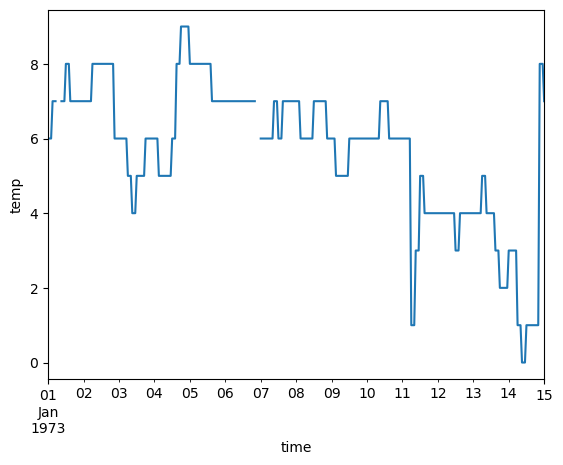

In [14]:
time_temperaturer.loc[start: start + timedelta(days=14)].plot(ylabel='temp')

Vi fyller inn data der data mangler ved å si at hvis data for en time mangler så setter vi inn den senest målte temperaturen.

In [15]:
time_temperaturer_ffill = time_temperaturer.ffill()

<Axes: xlabel='time', ylabel='temp'>

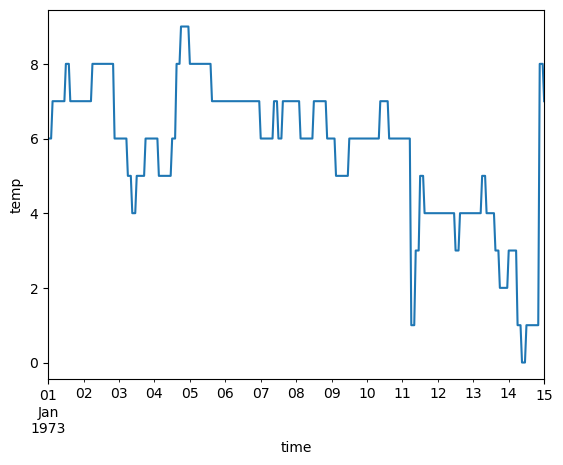

In [16]:
time_temperaturer_ffill.loc[start: start + timedelta(days=14)].plot(ylabel='temp')

### For senere bruk lagrer vi temperaturene til disk.

In [90]:
time_temperaturer_ffill.to_csv('time_temperaturer.csv', index='time')

#### Stemmer data under overens med hva du har erfart?

In [17]:
temp_siste_to_uker = temperaturer.loc[end - timedelta(days=14): end]

<Axes: xlabel='time'>

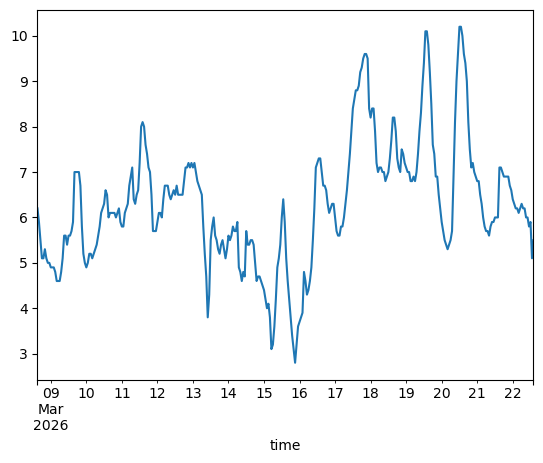

In [18]:
temp_siste_to_uker.plot()

In [28]:
#Vi leser inn tiden talt i timer fra første måling
t = (np.array(time_temperaturer.index) - np.array(time_temperaturer.index)[0]).astype(np.timedelta64(1, 'h')).astype(float)[:, None]

Jeg foretrekker å jobbe med numpy vektorer i stedet for pandas, så jeg leser ut data i `time_temperaturer` i en numpy vektor.

In [40]:
y = time_temperaturer_ffill.values.astype(float)[:, None]

Vi
setter kosten $S(\mathbf{x})$ til å være summen av kvadratene til
avvikene mellom målingene og linjen:
$$S(\mathbf{x}) = \sum_{i=1}^n (x_1t_i + x_2 - y_i)^2.$$

Skriver vi
$$A = \begin{bmatrix}t_1 & 1 \\ t_2 & 1 \\ \vdots & \vdots \\ t_n & 1\end{bmatrix} \quad \text{og} \quad
\mathbf{y}= \begin{bmatrix}y_1 \\ y_2 \\ \vdots \\ y_n\end{bmatrix},$$
er
$S(\vec{\mathbf{x}}) = |A\vec{\mathbf{x}} - \mathbf{y}|^2 = (A\vec{\mathbf{x}} - \mathbf{y}) \cdot (A\vec{\mathbf{x}} - \mathbf{y})$.



In [92]:
# Vi legger verdier inn i matrisen A
A = np.ones((t.size, 2))
A[:, 0] = t[:, 0]

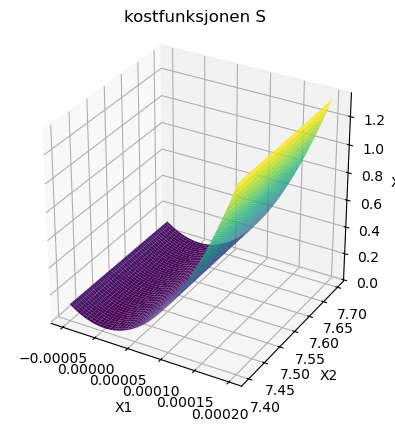

In [95]:
# @title Plotter
# Define the function
def S_fra_A_og_y(A, y):
    ATA = A.T@A
    ATy = A.T@y
    yy = y.T @y
    def f(x):
        z = np.vstack((x[0].reshape(1, x[0].size), x[1].reshape(1, x[1].size)))
        r1 = np.sum(z * (ATA @ z), axis=0)
        r2 = -2 * np.sum(z * ATy, axis=0)
        r3 = yy
        return (r1 + r2 + r3).reshape(x[0].shape)
    return f

# Create a grid of x and y values
x1 = np.linspace(-5e-5, 2e-4, 300)
x2 = np.linspace(7.4, 7.7, 300)
x = np.meshgrid(x1, x2)

# Compute the function values
S = S_fra_A_og_y(A, y)
x3 = S(x)

# # Mask values outside the unit disc
# mask = x**2 + y**2 > 1  # Create a boolean mask for points outside the unit disc
# z[mask] = np.nan  # Set values outside the unit disc to NaN (they won't be plotted)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(x[0], x[1], x3, cmap='viridis', edgecolor='none')

# Set labels
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])
ax.set_title('kostfunksjonen S');

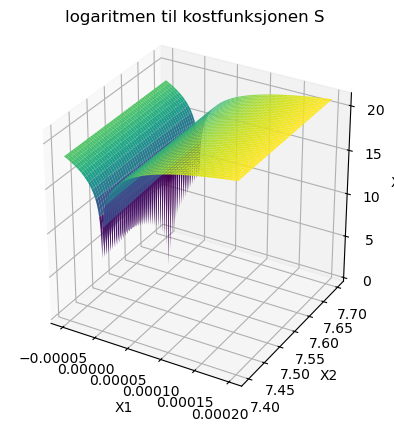

In [96]:
# @title Logaritmisk plot
# Define the function
def S_fra_A_og_y(A, y):
    ATA = A.T@A
    ATy = A.T@y
    yy = np.sum(y*y)
    def f(x):
        z = np.vstack((x[0].reshape(1, x[0].size), x[1].reshape(1, x[1].size)))
        r1 = np.sum(z * (ATA @ z), axis=0)
        r2 = -2 * np.sum(z * ATy, axis=0)
        r3 = yy
        return (r1 + r2 + r3).reshape(x[0].shape)
    return f

# Create a grid of x and y values
x1 = np.linspace(-5e-5, 2e-4, 300)
x2 = np.linspace(7.4, 7.7, 300)
x = np.meshgrid(x1, x2)

# Compute the function values
S = S_fra_A_og_y(A, y)
x3 = S(x)

# # Mask values outside the unit disc
# mask = x**2 + y**2 > 1  # Create a boolean mask for points outside the unit disc
# z[mask] = np.nan  # Set values outside the unit disc to NaN (they won't be plotted)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(x[0], x[1], np.log(x3 - np.min(x3) + 1), cmap='viridis', edgecolor='none')

# Set labels
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])
ax.set_title('logaritmen til kostfunksjonen S');

In [51]:
# La oss avlese verdier for minimumspunkt
minidx = np.argmin(x3)

In [52]:
# minste verdi vi har beregent for S(x)
x3.ravel()[minidx]

np.float64(17128127.63752931)

In [53]:
# leser ut tilhørende verdier av x1 og x2
x[0].ravel()[[minidx]], x[1].ravel()[[minidx]]

(array([2.67558528e-06]), array([7.59966555]))

In [54]:
# Hjelpestørrelser for analytisk beregning av av regresjonslinje

Ey = np.mean(y)
Eyt = np.mean(y * t)
Et = np.mean(t)
Ett = np.mean(t * t)

Husk: $x_1 = \frac{E(\mathbf{y}\mathbf{t}) - E(\mathbf{t})E(\mathbf{y})}{E(\mathbf{t}^2) - E(\mathbf{t})^2}$
og $x_2 = E(\mathbf{y}) - x_1E(\mathbf{t})$

In [55]:
# Beregner heldning og hvor regresjonslinje krysser y-aksen
x1 = (Eyt - Et * Ey)/(Ett - Et * Et)
x2 = Ey - x1 * Et

# Legger x1 og x2 inn i en vektor
xx = np.array([[x1],[x2]])

# Beregner regresjonslinjen
L= x1 * t + x2

**Vi lagrer regresjonslinjen for senere bruk**

In [56]:
# Kostverdien for det analytisk beregnede minimumspunkt
S(xx)

array([17127842.01946659])

In [97]:
np.sum((L - y)**2)

np.float64(17127842.019465677)

In [98]:
np.mean((L - y)**2)

np.float64(36.713506441139906)

Text(0.5, 0, 'timer fra første temperaturmåling')

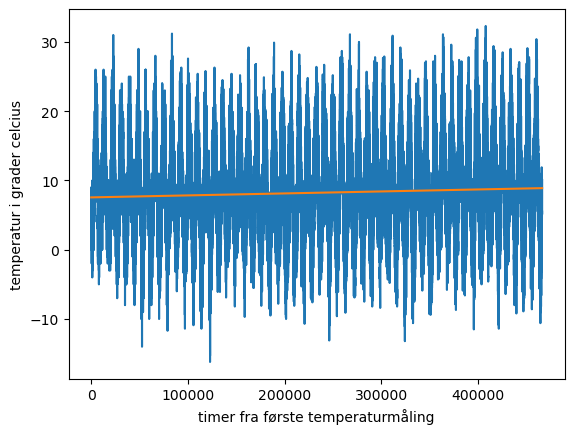

In [61]:
plt.plot(y)
plt.plot(L)
plt.ylabel('temperatur i grader celcius')
plt.xlabel('timer fra første temperaturmåling')


Vi kan sjekke om vår beregning stemmer overens med sklearn sin beregning:

In [65]:
t.shape, y.shape

((466527, 1), (466527, 1))

In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
regr = LinearRegression()
regr.fit(t, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
Lsk = regr.predict(t)

In [67]:
np.allclose(L, Lsk)

True

In [82]:
rolling_mean = time_temperaturer_ffill.rolling(5 * 24 * 365, center=True).mean().values

### <font color='DarkCyan'> Spørsmål:</font>

<font color='Crimson'>Hva forteller figuren under til oss?</font>

Text(0.5, 0, 'timer fra første temperaturmåling')

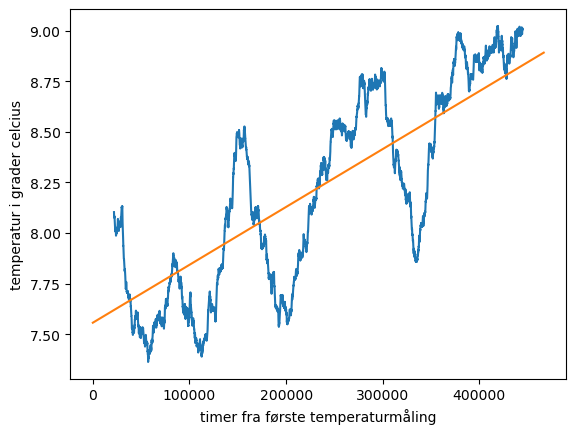

In [84]:
plt.plot(rolling_mean)
plt.plot(L)
plt.ylabel('temperatur i grader celcius')
plt.xlabel('timer fra første temperaturmåling')


## Hypotese:

**Temperaturen har steget med minst en grad siden temperaturmålingen begynte**

[Vi går videre og ser om vi kan forbedre den lineære modellen av temperaturutviklingen ved å inkludere periodiske svingninger i temperaturen.](Variasjoner_temperatur.ipynb)